# Contents 

1. [Initialisation]

# 1. Initialisation

In [324]:
import numpy as np
from scipy.linalg import expm
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import qibo
from qibo import hamiltonians, set_backend, Circuit, symbols
from qibo.gates import Unitary
from qibo.symbols import *
set_backend("numpy")

[Qibo 0.2.22|INFO|2025-12-23 23:37:49]: Using numpy backend on /CPU:0


## 1.1 Define initial variables
[top](#Contents) 

Choose number of qubits and Hamiltonian

In [325]:
#Number of qubits
L = 9
#Size of system
n = 2**L 
nsqrd = n**2
#Heisenberg Hamiltonian
H_def = sum([ Z(x)*Z(x+1) +X(x)*X(x+1) + Y(x)*Y(x+1)  for x in range(L-1)]) 
H_sh = hamiltonians.SymbolicHamiltonian(H_def)
H = H_sh.matrix
#minimum energy
target_energy = min(np.linalg.eigvalsh(H))
print("Target energy: ", target_energy)

[Qibo 0.2.22|WARNING|2025-12-23 23:37:49]: Calculating the dense form of a symbolic Hamiltonian. This operation is memory inefficient.


Target energy:  -14.945286825517293


## Choose initial state

In [326]:
def select_initial_state( init_type = None ):
    if init_type == "lowest energy":
        #basis vector with lowest energy
        es_ini = []
        for i in range(2**L):
            psi0 = np.zeros([1,2**L]).T
            psi0[i] = 1
            es_ini.append(H_sh.expectation(psi0.T[0]))
        min(es_ini)
        psi0 = np.zeros([1,2**L]).T
        psi0[np.argmin(es_ini)] = 1
        PSI0 = psi0 @ psi0.conj().T
        return psi0 , PSI0
    if init_type == "last":
        #last basis vector
        psi0 = np.zeros([1,2**L]).T
        psi0[-1] = 1
        PSI0 = psi0 @ psi0.conj().T
        return psi0 , PSI0
    if init_type == "first" or init_type is None:
        #first basis vector
        psi0 = np.zeros([1,2**L]).T
        psi0[0] = 1
        PSI0 = psi0 @ psi0.conj().T
        return psi0 , PSI0
    
psi0, PSI0 = select_initial_state("lowest energy") 

## Define Plotting Functions

In [327]:
def energy_plot(data):
    plt.rcParams['axes.labelsize'] = 14
    plt.rcParams['axes.titlesize'] = 14
    plt.rcParams['font.size'] = 12
    plt.rcParams['savefig.dpi'] = 75
    plt.rcParams['lines.linewidth'] = 2.0
    plt.rcParams['lines.markersize'] = 8
    plt.rcParams['legend.fontsize'] = 12
    plt.rcParams['legend.labelspacing'] = .3
    plt.rcParams['legend.columnspacing']= .3
    plt.rcParams['legend.handletextpad']= .1
    plt.rcParams['text.usetex'] = True
    plt.rcParams['font.family'] = "serif"
    plt.rcParams['font.serif'] = "cm"
    plt.rcParams["figure.figsize"] = [5, 3.50]
    plt.rcParams["figure.autolayout"] = True

    # for result in results:
    for datum in data:
        energies = [element[0] if not np.isnan(element[0]) else 0 for element in datum["results"]]
        plt.plot(energies, label=datum["label"], marker=datum["marker"], linestyle='-')

    #axes start and end
    # plt.xlim(0, data["iterations"]+2)
    plt.xlim(0, 10)
    
    #set ticks
    # plt.xticks(range(0,data["iterations"]+2))
    plt.xticks(range(0,11))
    plt.yticks(sorted(np.round([tick[0] for tick in data[0]["results"][:4]] + [target_energy], 2)))

    plt.xlabel("Iteration")
    plt.ylabel("Energy")
    plt.grid(True)
    # plt.axline((0, target_energy), (data["iterations"]+1,target_energy), label=f"$E_* = {np.round(target_energy,2)}$", linestyle = ":" )
    plt.axline((0, target_energy), (10,target_energy), label=f"$E_* = {np.round(target_energy,2)}$", linestyle = ":" )
    plt.legend()
    plt.show()

def grid_plot(mus, gammas, energies):
    return

def heat_plot(mus, gammas, energies, points):
    plt.figure()
    plt.rcParams["figure.autolayout"] = True
    plt.rcParams['text.usetex'] = True
    plt.pcolormesh(
    gammas, mus, energies,
    shading='nearest',
    cmap='RdBu')
    color_bar = plt.colorbar()

    for p in points:
        plt.plot(p["x"], p["y"], label=p["label"], marker='o', color='black', markersize=8)
        # Reference lines
        plt.axhline(p["y"], color='black', linewidth=1)
        plt.axvline(p["x"], color='black', linewidth=1)
        plt.xticks(sorted([-1, p["x"], 3]))
        plt.yticks(sorted([0, p["y"], 3]))
        
    ax = plt.gca()
    ax.tick_params(axis='both', labelsize=8)
    ax.tick_params(axis="x", labelrotation=90)

    
    plt.xlim(-1,3)
    plt.ylim(0,3)
    plt.xlabel("$\gamma$")
    plt.ylabel("$\mu$")
    plt.title("$f(e^{-\mu R_k -\gamma W_{k-1}})$")
    ax.legend(loc='best')
    plt.show()

<>:68: SyntaxWarning: invalid escape sequence '\g'
<>:69: SyntaxWarning: invalid escape sequence '\m'
<>:70: SyntaxWarning: invalid escape sequence '\m'
<>:68: SyntaxWarning: invalid escape sequence '\g'
<>:69: SyntaxWarning: invalid escape sequence '\m'
<>:70: SyntaxWarning: invalid escape sequence '\m'
/var/folders/42/rs6w9b8x4yg3j67lsn2hxcqc0000gn/T/ipykernel_94525/3634920267.py:68: SyntaxWarning: invalid escape sequence '\g'
  plt.xlabel("$\gamma$")
/var/folders/42/rs6w9b8x4yg3j67lsn2hxcqc0000gn/T/ipykernel_94525/3634920267.py:69: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$\mu$")
/var/folders/42/rs6w9b8x4yg3j67lsn2hxcqc0000gn/T/ipykernel_94525/3634920267.py:70: SyntaxWarning: invalid escape sequence '\m'
  plt.title("$f(e^{-\mu R_k -\gamma W_{k-1}})$")


## 1.2 Define Auxiliary Maths functions

In [328]:
def dotProd(A,B):
    #HS dot product, if A,B antihermitian then this is real
    return (1/2) * np.trace(A @ (B.conj().T)).real

def commutator(A,B):
    #Implement [A,B]
    return A @ B - B @ A

def dagger(A):
    return A.conj().T

def cost_func(U):
    #E = <psi|H|psi>
    return np.trace(dagger(U) @ H @ U @ PSI0).real

def compute_moments(U):
    #Compute expected value <H>, <H^2>, and variance
    E = cost_func(U)
    S = np.trace(dagger(U) @ H @ H @ U @ PSI0).real
    return [E, S, S - E**2]
compute_moments(np.eye(n))

[np.float64(-8.0), np.float64(96.0), np.float64(32.0)]

## Define $\mu$, $\gamma$ selectors

In [329]:
def mu_line_search(U, W, prevW=0):
    vals = np.linspace(0, 3, 30)
    energies = [compute_moments(expm(-val * W) @ U)[0] for val in vals]
    ind = np.argmin(energies)
    if np.size(prevW)==1:
        return vals[ind]
    else:
        return (vals[ind], 0)

def mu_poly_approx(U, W):
    return 

def mu_gamma_grid_searchA(U, R, prevW):
    num = 30
    special_points = []
    mu_vals = np.linspace(0.001, 3, num)
    gamma_vals = np.linspace(-1,3,num)
    energies = [[ compute_moments(expm(-x * R -y * prevW) @ U )[0] for y in gamma_vals ] for x in mu_vals]
    ind = np.argmin(energies)
    row, col = np.unravel_index(ind, (num,num))

    mu_min = mu_vals[row]
    gamma_min = gamma_vals[col]
    special_points.append({"x": gamma_min, "y": mu_min, "energy": energies[row][col], "label": "$E_\mathrm{min}$"})
    heat_plot(mu_vals, gamma_vals, energies, special_points)
    # input()
    
    if mu_vals[row] == 0:
        return (0,0)
    else:
        return (mu_vals[row], gamma_vals[col]/mu_vals[row])

def mu_gamma_auto_PR_approx(U, R, prevW):
    return

<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
/var/folders/42/rs6w9b8x4yg3j67lsn2hxcqc0000gn/T/ipykernel_94525/3931294195.py:24: SyntaxWarning: invalid escape sequence '\m'
  special_points.append({"x": gamma_min, "y": mu_min, "energy": energies[row][col], "label": "$E_\mathrm{min}$"})


## Define CG functions

In [330]:
def general_cg(mu_selector, mu_gamma_selector, label, marker, initial_U=np.eye(n), iterations=15, tolerance=0.1):
    R = commutator(H, initial_U@PSI0@dagger(initial_U)) #Riemannian gradient
    RdotR = dotProd(R,R) #Size of gradient. If 0, U is a minimum
    results = []
    mu_mins = []
    gamma_mins = [0]
    moments = compute_moments(initial_U)
    # print("cost at k=0 is", moments[0])
    # print("Size of Gadient at k=0 is", RdotR)

    results.append(moments)
    if RdotR < tolerance:
        return results
    
    #Take a SD step
    W = R #intial search direction 
    mu_min = mu_selector(initial_U, W)
    mu_mins.append(mu_min)
    U = expm(-mu_min*W)@initial_U
    moments = compute_moments(U)
    results.append(moments)

    #Take CG steps
    k=1
    prevW = W.copy() #previous search direction
    R = commutator(H, U@PSI0@dagger(U)) #new steepest descent direction
    RdotR = dotProd(R,R)
    # print("cost at k=1 is", moments[0])
    # print("Size of Gadient at k="+ str(k)+" is "+str(RdotR))

    while RdotR > tolerance and k < iterations:
        mu_min, gamma_min = mu_gamma_selector(U, R, prevW) #select mu and gamma
        gamma_mins.append(gamma_min)
        mu_mins.append(mu_min)
        W = R + gamma_min*prevW #CG search direction

        if dotProd(W, R) < 0: #if W not a descent direction then make W = R
            W = R
        
        U = expm(-mu_min*W) @ U
        moments = compute_moments(U)
        results.append(moments)

        prevW = W.copy() #previous search direction
        R = commutator(H, U@PSI0@dagger(U)) #new steepest descent direction
        RdotR = dotProd(R,R)
        k += 1 
        # print("Cost at k="+str(k)+" is "+str(moments[0]))
        # print("Size of gradient at k="+ str(k)+ " is "+ str(RdotR))
        
    #results is [E, S, Variance] of each U, k is number of iterations, 
    # mu_mins and gamma_mins are chioices for mu, gamma at each step
    return {"results": results, "iterations": k, "mus": mu_mins, "gammas": gamma_mins, "label":label, "marker": marker}

## Simulations

<>:3: SyntaxWarning: invalid escape sequence '\g'
<>:4: SyntaxWarning: invalid escape sequence '\g'
<>:3: SyntaxWarning: invalid escape sequence '\g'
<>:4: SyntaxWarning: invalid escape sequence '\g'
/var/folders/42/rs6w9b8x4yg3j67lsn2hxcqc0000gn/T/ipykernel_94525/4036462269.py:3: SyntaxWarning: invalid escape sequence '\g'
  toplot.append(general_cg(mu_line_search, mu_gamma_grid_searchA, "$\gamma_k = \gamma_\mathrm{min}$", "*"))
/var/folders/42/rs6w9b8x4yg3j67lsn2hxcqc0000gn/T/ipykernel_94525/4036462269.py:4: SyntaxWarning: invalid escape sequence '\g'
  toplot.append(general_cg(mu_line_search, mu_line_search, "$\gamma_k = 0$", "^"))


target energy is -14.945286825517293


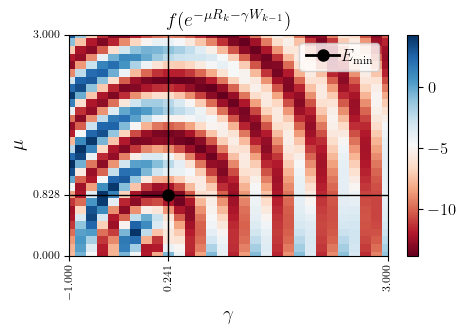

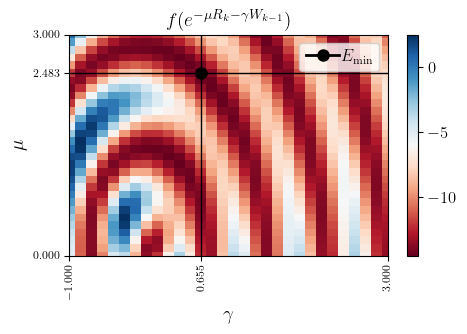

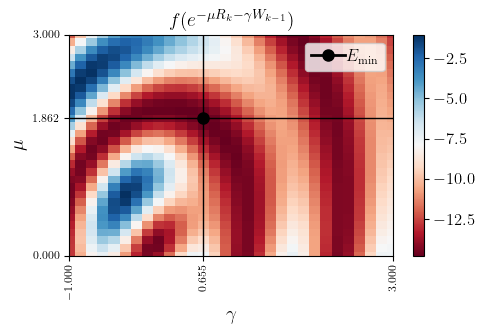

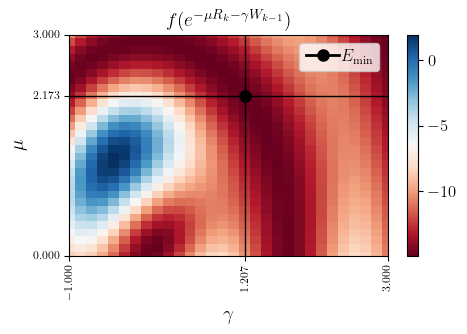

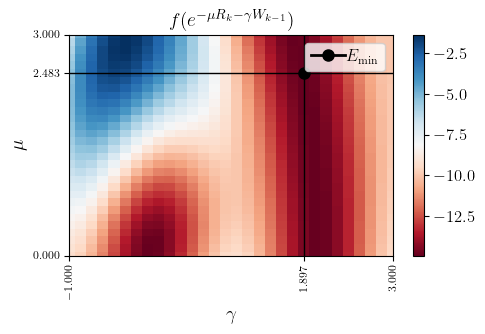

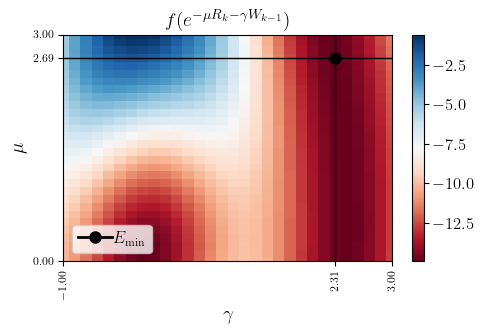

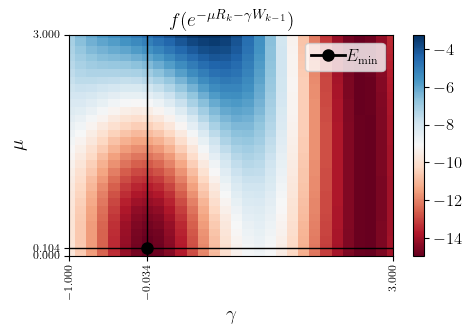

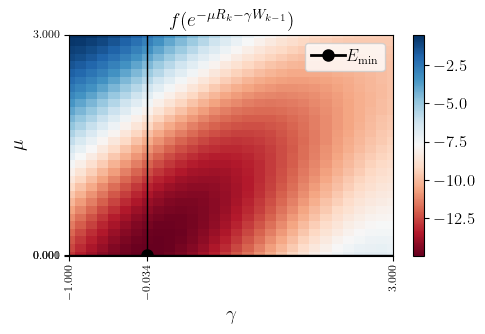

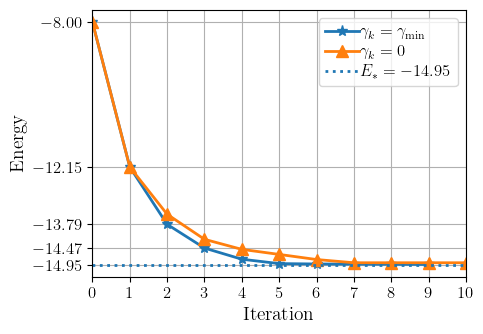

In [331]:
print("target energy is", target_energy)
toplot = []
toplot.append(general_cg(mu_line_search, mu_gamma_grid_searchA, "$\gamma_k = \gamma_\mathrm{min}$", "*"))
toplot.append(general_cg(mu_line_search, mu_line_search, "$\gamma_k = 0$", "^"))
energy_plot(toplot)